In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,confusion_matrix , classification_report, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib
df= pd.read_csv('../data/creditcard.csv')
df.shape

I0000 00:00:1783765728.764714    4534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783765728.769245    4534 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783765729.092296    4534 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783765731.180588    4534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

(284807, 31)

In [3]:
X= df.drop('Class' , axis=1)  # here X is the values other than the first column class
Y= df['Class']     # here Y is the values of class that is whether it is 0 or 1


In [4]:
X_train , X_temp, Y_train, Y_temp = train_test_split(         # we are dividing the data set into training set(60% of data) and the rest 40%
    X,Y,test_size=0.4, stratify= Y,random_state=42)           # which is for testing

In [5]:
X_val,X_test, Y_val, Y_test= train_test_split(                            # the testing set is further divided by 50% ie finally 20% for test set
    X_temp, Y_temp, test_size=0.5, stratify = Y_temp, random_state=42)    # and the last 20% for validation set 

In [6]:
print(X_train.shape, X_val.shape, X_test.shape)          
print(Y_train.value_counts(normalize=True))
print(Y_val.value_counts(normalize=True))
print(Y_test.value_counts(normalize=True))

(170884, 30) (56961, 30) (56962, 30)
Class
0    0.998274
1    0.001726
Name: proportion, dtype: float64
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64
Class
0    0.998262
1    0.001738
Name: proportion, dtype: float64


In [7]:
scaler= StandardScaler()                        # this is used to scale the data to close to 0 such that mean is ~= 0
X_train_scaled= X_train.copy()
X_val_scaled= X_val.copy()
X_test_scaled= X_test.copy()


In [8]:
X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_val_scaled[['Time', 'Amount']] = scaler.transform(X_val[['Time', 'Amount']]) 
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])    


In [9]:
X_train_scaled[['Time','Amount']].describe()

,Time,Amount
count,1.708840e+05,1.708840e+05
mean,-9.613392e-17,-1.297309e-17
std,1.000003e+00,1.000003e+00
min,-1.998447e+00,-3.461907e-01
25%,-8.559157e-01,-3.237192e-01
50%,-2.111681e-01,-2.598675e-01
75%,9.363520e-01,-4.278734e-02
max,1.638776e+00,1.002317e+02


In [10]:
#starting model-1 logistic regression                               

log_reg= LogisticRegression(max_iter=1000,random_state=42)       #max iter is the total number of times its running the regression 
log_reg.fit(X_train_scaled,Y_train)           # we are plotting graph for this and getting the optimal values of w and b parameters

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [11]:
y_val_pred_lr= log_reg.predict(X_val_scaled)    # we are now predicting using our model on the validation set

In [12]:

print("Logistic Regression - Validation Results")                   
print(classification_report(Y_val, y_val_pred_lr, digits=4))            #classification_report is what is helping us decide the accuracy of the models
print(confusion_matrix(Y_val, y_val_pred_lr))

Logistic Regression - Validation Results
              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56863
           1     0.8267    0.6327    0.7168        98

    accuracy                         0.9991     56961
   macro avg     0.9130    0.8162    0.8582     56961
weighted avg     0.9991    0.9991    0.9991     56961

[[56850    13]
 [   36    62]]


In [13]:
#starting decision tree model-2

for depth in [3, 5, 7, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)          
    dt.fit(X_train_scaled, Y_train)
    y_val_pred_dt = dt.predict(X_val_scaled)                              #usually the best depth for such trees is one of 3,5,7
    print(f"--- max_depth={depth} ---")
    print(classification_report(Y_val, y_val_pred_dt, digits=4))

--- max_depth=3 ---
              precision    recall  f1-score   support

           0     0.9995    0.9996    0.9996     56863
           1     0.7553    0.7245    0.7396        98

    accuracy                         0.9991     56961
   macro avg     0.8774    0.8620    0.8696     56961
weighted avg     0.9991    0.9991    0.9991     56961

--- max_depth=5 ---
              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9996     56863
           1     0.8202    0.7449    0.7807        98

    accuracy                         0.9993     56961
   macro avg     0.9099    0.8723    0.8902     56961
weighted avg     0.9993    0.9993    0.9993     56961

--- max_depth=7 ---
              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9996     56863
           1     0.8222    0.7551    0.7872        98

    accuracy                         0.9993     56961
   macro avg     0.9109    0.8774    0.8934     56961
weighted avg  

In [14]:
best_dt = DecisionTreeClassifier(max_depth=7, random_state=42)  #from above we can see that 7 is the best depth and we are using this to run decision tree
best_dt.fit(X_train_scaled, Y_train)
y_val_pred_dt = best_dt.predict(X_val_scaled)
print(classification_report(Y_val, y_val_pred_dt, digits=4))

              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9996     56863
           1     0.8222    0.7551    0.7872        98

    accuracy                         0.9993     56961
   macro avg     0.9109    0.8774    0.8934     56961
weighted avg     0.9993    0.9993    0.9993     56961



In [15]:
results=[]

def add_result(name,y_true,y_predict):
    results.append({
        'model':name,
        'precision' : precision_score(y_true,y_predict),              # we are storing the data we get in an array so that we can convert it later into a dataframe
        'recall' : recall_score(y_true,y_predict),
        'f1' : f1_score(y_true,y_predict)})
    
            

In [16]:
add_result('Logistic Regression', Y_val, y_val_pred_lr)
add_result('Decision Tree', Y_val, y_val_pred_dt)

results_df = pd.DataFrame(results)
results_df

,model,precision,recall,f1
0,Logistic Regression,0.826667,0.632653,0.716763
1,Decision Tree,0.822222,0.755102,0.787234


In [17]:
#starting model3 random forest classifier

rf = RandomForestClassifier(
    n_estimators=100,                               # n_estimators is the number of trees we are taking 
    max_depth=10, 
    random_state=42,
    n_jobs=-1)                                      # n_jobs = -1 ensures all cores are doing this in parallel as randomforest is a parallel process
rf.fit(X_train_scaled,Y_train)
y_val_pred_rfc = rf.predict(X_val_scaled)
print(classification_report(Y_val,y_val_pred_rfc,digits=4))

              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     56863
           1     0.9241    0.7449    0.8249        98

    accuracy                         0.9995     56961
   macro avg     0.9618    0.8724    0.9123     56961
weighted avg     0.9994    0.9995    0.9994     56961



In [18]:
scale_pos_weight = (Y_train == 0).sum() / (Y_train == 1).sum() #for the xgbclassifier we need to balance the positive and negative classes by assigning more weight to the minority class, preventing the model from becoming biased toward the majority class
print(scale_pos_weight)

578.2677966101695


In [19]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,               #xgbclassifier is basically a multiple decision trees that run sequentially like the next decision tree fixes the mistakes of the previous decision tree to achieve maximum efficiency 
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric= 'logloss')
xgb_model.fit(X_train_scaled,Y_train)
y_val_pred_xgb= xgb_model.predict(X_val_scaled)
print(classification_report(Y_val,y_val_pred_xgb,digits=4))

              precision    recall  f1-score   support

           0     0.9996    0.9996    0.9996     56863
           1     0.7857    0.7857    0.7857        98

    accuracy                         0.9993     56961
   macro avg     0.8927    0.8927    0.8927     56961
weighted avg     0.9993    0.9993    0.9993     56961



In [20]:
add_result("Random forest",Y_val,y_val_pred_rfc)
add_result("XGBoost",Y_val,y_val_pred_xgb)
results_df = pd.DataFrame(results)
results_df


,model,precision,recall,f1
0,Logistic Regression,0.826667,0.632653,0.716763
1,Decision Tree,0.822222,0.755102,0.787234
2,Random forest,0.924051,0.744898,0.824859
3,XGBoost,0.785714,0.785714,0.785714


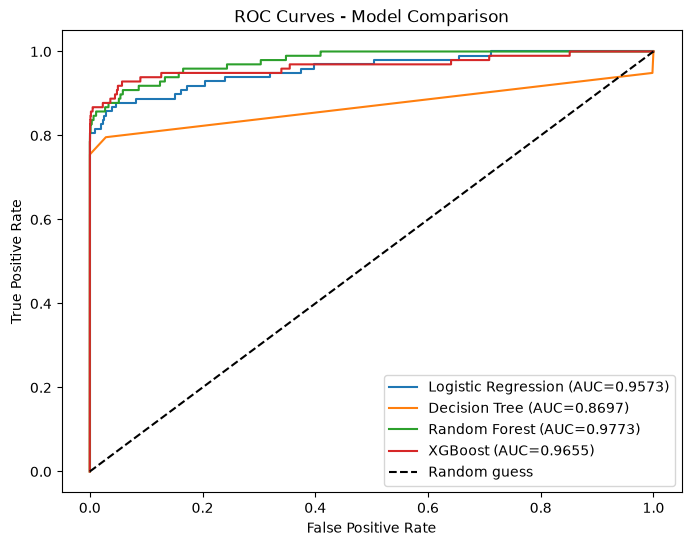

In [21]:
plt.figure(figsize=(8,6))

for name, model in [('Logistic Regression', log_reg),
                     ('Decision Tree', best_dt),
                     ('Random Forest', rf),
                     ('XGBoost', xgb_model)]:
    y_prob = model.predict_proba(X_val_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(Y_val, y_prob)                  # plotting the various graphs using the probability to visually compare the better model
    auc = roc_auc_score(Y_val, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.show()

-> Random Forest is currently my best model on both F1 and AUC — it has by far the highest precision (92.4%), meaning when it flags something as fraud, it's rarely wrong, while still catching a solid 74.5% of actual fraud cases.

-> XGBoost has the most balanced precision/recall (both ~0.786) — this makes sense given the scale_pos_weight adjustment, which explicitly told it to weight fraud cases ~578x more, pushing it to catch more fraud at the cost of some extra false alarms compared to Random Forest.

-> Decision Tree's AUC (0.88) is noticeably lower than the other three (~0.96-0.98) — a single tree's ROC curve is "blockier"/less smooth (we can see this in the plot — the orange line is visibly more jagged), since it only has a limited number of distinct probability outputs compared to ensemble methods.

-> Logistic regression has the lowest recall (63%) — it's the most conservative model, missing more actual fraud cases than the tree-based models. This is a reasonable real-world talking point: linear decision boundaries struggle more with this data than tree-based splits do.

In [22]:
#model-5 neural networks

nn_model = keras.Sequential([
    
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),             #neural network using three stages and a final sigmoid activation function
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
    
                 
    

E0000 00:00:1783765791.314485    4534 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [23]:
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',       #usage of binarycross entropy for loss function and an adam optimizer 
    metrics=['Precision','Recall'])

    

In [24]:
neg = (Y_train == 0).sum()
pos = (Y_train == 1).sum()                    #similar to xgboost we also need to balance the weight with this method
class_weight = {0: 1.0, 1:neg/pos}
print(class_weight)

{0: 1.0, 1: np.float64(578.2677966101695)}


In [25]:
history = nn_model.fit(
    X_train_scaled,Y_train,
    validation_data= (X_val_scaled, Y_val),
    epochs= 20,                    #epochs are the different times we are running the nn to improve accuracy 
    batch_size= 2048,
    class_weight=class_weight,
    verbose=1)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Precision: 0.0047 - Recall: 0.9085 - loss: 0.7830 - val_Precision: 0.0611 - val_Recall: 0.8571 - val_loss: 0.3625
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Precision: 0.0916 - Recall: 0.8881 - loss: 0.4388 - val_Precision: 0.0797 - val_Recall: 0.8469 - val_loss: 0.2035
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Precision: 0.0958 - Recall: 0.9051 - loss: 0.3177 - val_Precision: 0.0891 - val_Recall: 0.8469 - val_loss: 0.1321
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Precision: 0.0942 - Recall: 0.9153 - loss: 0.2661 - val_Precision: 0.0792 - val_Recall: 0.8571 - val_loss: 0.1206
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Precision: 0.0924 - Recall: 0.9288 - loss: 0.2371 - val_Precision: 0.1011 - val_Recall: 0.8673 - val_loss: 0.0913
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Precision: 0.0969 - Recall: 0.9322 - loss: 0.2205 - val_Precision: 0.0994 - val_Recall: 0.8776 - val_loss: 0.0851
Epoc

In [26]:
y_val_prob_nn = nn_model.predict(X_val_scaled).flatten()
y_val_pred_nn = (y_val_prob_nn >= 0.5).astype(int)     #in neural networks we get the probability so we need to derive prediction(whether it is a fraud or not) for each case
print(classification_report(Y_val,y_val_pred_nn,digits=4))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 783us/step
              precision    recall  f1-score   support

           0     0.9998    0.9848    0.9922     56863
           1     0.0898    0.8673    0.1627        98

    accuracy                         0.9846     56961
   macro avg     0.5448    0.9261    0.5775     56961
weighted avg     0.9982    0.9846    0.9908     56961



In [27]:
add_result('Neural Network', Y_val, y_val_pred_nn)
results_df = pd.DataFrame(results)
results_df

,model,precision,recall,f1
0,Logistic Regression,0.826667,0.632653,0.716763
1,Decision Tree,0.822222,0.755102,0.787234
2,Random forest,0.924051,0.744898,0.824859
3,XGBoost,0.785714,0.785714,0.785714
4,Neural Network,0.089757,0.867347,0.162679


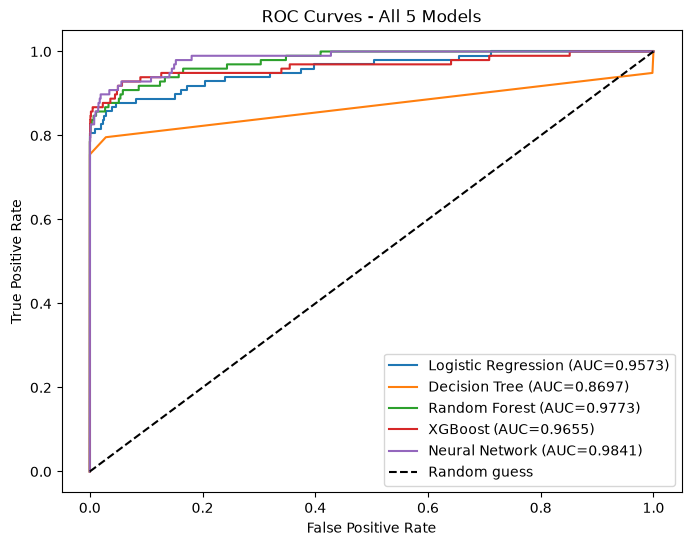

In [28]:
plt.figure(figsize=(8,6))

models_for_roc = [
    ('Logistic Regression', log_reg.predict_proba(X_val_scaled)[:, 1]),
    ('Decision Tree', best_dt.predict_proba(X_val_scaled)[:, 1]),
    ('Random Forest', rf.predict_proba(X_val_scaled)[:, 1]),
    ('XGBoost', xgb_model.predict_proba(X_val_scaled)[:, 1]),
    ('Neural Network', y_val_prob_nn)
]

for name, y_prob in models_for_roc:
    fpr, tpr, _ = roc_curve(Y_val, y_prob)
    auc = roc_auc_score(Y_val, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All 5 Models')
plt.legend()
plt.show()

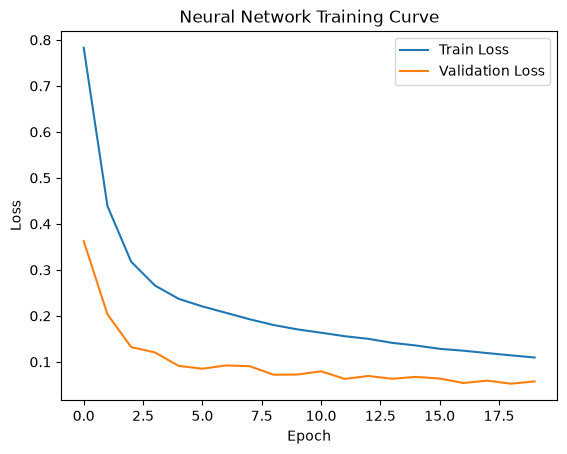

In [29]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Neural Network Training Curve')
plt.legend()
plt.show()

In [30]:
results_df

,model,precision,recall,f1
0,Logistic Regression,0.826667,0.632653,0.716763
1,Decision Tree,0.822222,0.755102,0.787234
2,Random forest,0.924051,0.744898,0.824859
3,XGBoost,0.785714,0.785714,0.785714
4,Neural Network,0.089757,0.867347,0.162679


In [31]:
y_val_pred_best = rf.predict(X_val_scaled)       #from above we can see that randomforest classifier gives the best accuracy so we are using it to check our errors
y_val_prob_best = rf.predict_proba(X_val_scaled)[:, 1]

results_val = X_val.copy()
results_val['actual'] = Y_val.values                   
results_val['predicted'] = y_val_pred_best
results_val['fraud_probability'] = y_val_prob_best

In [32]:
false_negatives = results_val[(results_val['actual']==1) & (results_val['predicted']==0)]
false_positives = results_val[(results_val['actual']==0) & (results_val['predicted']==1)]  #finding the number of false alarms and fraud cases that were missed by the model 

print(f'Number of false negatives(misseed fraud) is {len(false_negatives)}')    
print(f'Number of false positives(false alarms) is {len(false_positives)}')

Number of false negatives(misseed fraud) is 25
Number of false positives(false alarms) is 6


In [33]:
false_positives[['Amount','fraud_probability']].describe()   # helps us know which type of cases the model is not able to predict properly 
false_positives.sort_values('fraud_probability',ascending=False).head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,actual,predicted,fraud_probability
16110,27524.0,-26.619952,14.845545,-27.747084,6.408105,-19.025741,-5.053209,-19.041960,17.573712,-3.695863,...,-1.210123,0.150261,1.879262,-0.225019,1.257380,0.451777,1.00,0,1,0.970000
14920,26217.0,-17.950631,11.067069,-20.742660,6.075531,-13.389765,-4.532888,-15.188146,12.101062,-4.026880,...,-0.705046,0.102040,1.177477,-0.238730,1.554463,0.547948,1.00,0,1,0.892500
16851,28233.0,-0.459787,2.869443,-5.412617,3.893741,-1.920080,-2.759995,-4.260113,0.878554,-2.636499,...,-0.281806,-0.057908,1.077772,-0.198859,1.163969,0.610418,1.00,0,1,0.786017
43418,41501.0,-31.746663,17.418649,-31.813586,6.590421,-22.245025,-4.827882,-22.291962,17.941363,-3.776069,...,-1.178763,0.149984,2.205306,-0.230525,1.063696,0.437115,1.00,0,1,0.780000
190263,128759.0,-1.272117,1.827615,-3.810610,0.583759,-0.641242,-1.389043,-1.954054,1.173920,-2.053191,...,0.083079,0.741676,-0.173234,0.534870,0.183562,0.020316,0.76,0,1,0.629635
277737,167826.0,-6.629470,2.872588,-4.817947,0.799106,-2.842538,-1.941351,-4.609837,2.130611,-1.582576,...,-0.621414,0.086836,0.233894,-0.256196,-1.861764,0.261256,1.00,0,1,0.500448


In [34]:

joblib.dump(rf, '../models/fraud_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved.")

Model and scaler saved.


In [35]:
nn_model.save('../models/fraud-model.keras')

In [36]:
feature_names = X_train.columns.tolist()
print(feature_names)
print(len(feature_names))

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
30
